In [ ]:
from pyhycom import ab2nc

# Requires archv.a, archv.b, regional.depth.a, regional.depth.b, regional.grid.a, regional.grid.b
ab2nc('/Users/mikesmith/Downloads/rtofs/rtofs.20231013/rtofs_glo.t00z.f12.archv.a')

In [29]:
import xarray as xr

ds = xr.open_dataset('/Users/mikesmith/Documents/github/ioos_model_comparisons/rtofs_glo.t00z.f12.archv.nc')

In [2]:
ds

<xarray.Dataset> Size: 20GB
Dimensions:             (time: 1, Y: 3298, X: 4500, layer: 41)
Coordinates:
  * time                (time) datetime64[ns] 8B 2023-10-10T12:00:00
  * layer               (layer) float32 164B 1.0 2.0 3.0 4.0 ... 39.0 40.0 41.0
Dimensions without coordinates: Y, X
Data variables: (12/24)
    longitude           (Y, X) float32 59MB ...
    latitude            (Y, X) float32 59MB ...
    bathymetry          (Y, X) float32 59MB ...
    montg1              (time, Y, X) float32 59MB ...
    srfhgt              (time, Y, X) float32 59MB ...
    SSH                 (time, Y, X) float32 59MB ...
    ...                  ...
    thknss              (time, layer, Y, X) float32 2GB ...
    layer_bottom_depth  (time, layer, Y, X) float32 2GB ...
    layer_middle_depth  (time, layer, Y, X) float32 2GB ...
    layer_top_depth     (time, layer, Y, X) float32 2GB ...
    temp                (time, layer, Y, X) float32 2GB ...
    salin               (time, layer, Y, X) float32 2GB ...
Attributes:
    description:  HYCOM output on the native hybrid layers.
    history:      Converted from HYCOM .[ab] format to NetCDF using the ab2nc...

In [3]:
import numpy as np

# Define your target depth grid (as you provided before)
target_depths = np.array([0.00, 2.00, 4.00, 6.00, 8.00, 10.00, 12.00, 15.00, 20.00, 25.00, 30.00, 
                          35.00, 40.00, 45.00, 50.00, 60.00, 70.00, 80.00, 90.00, 100.00, 125.00, 
                          150.00, 200.00, 250.00, 300.00, 350.00, 400.00, 500.00, 600.00, 700.00, 
                          800.00, 900.00, 1000.00, 1250.00, 1500.00, 2000.00, 2500.00, 3000.00, 
                          4000.00, 5000.00], dtype=np.float32)


In [4]:
# Use the 'layer_middle_depth' to reference the vertical layers
layer_depths = ds['layer_middle_depth'].isel(time=0)  # Depths at each layer
layer_depths

<xarray.DataArray 'layer_middle_depth' (layer: 41, Y: 3298, X: 4500)> Size: 2GB
[608481000 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 2023-10-10T12:00:00
  * layer    (layer) float32 164B 1.0 2.0 3.0 4.0 5.0 ... 38.0 39.0 40.0 41.0
Dimensions without coordinates: Y, X
Attributes:
    long_name:    Depth of HYCOM Layer (Middle)
    description:  Depth of the middle of the HYCOM layer.
    units:        m

In [6]:
from scipy.interpolate import interp1d

# List of variables you want to interpolate (e.g., temp, salin, u-vel, v-vel)
variables_to_interpolate = ['temp', 'salin', 'u-vel', 'v-vel']

# Create an empty dictionary to store interpolated variables
interpolated_vars = {}

# Vectorized interpolation using NumPy
for var in variables_to_interpolate:
    print(f"Interpolating {var}...")

    # Extract the data for the current variable (3D: time, layer, Y, X)
    data_var = ds[var].isel(time=0).values  # Extract the variable values as a NumPy array
    
    # Perform the interpolation in a vectorized way using np.interp
    interpolated_data = np.apply_along_axis(
        lambda profile: np.interp(target_depths, layer_depths[:, 0, 0], profile, left=np.nan, right=np.nan),
        axis=0, arr=data_var
    )
    
    # Store the interpolated variable in the dictionary
    interpolated_vars[var] = interpolated_data

Interpolating temp...


KeyboardInterrupt: 

In [ ]:
# Create a new xarray Dataset to store interpolated variables
ds_interpolated = xr.Dataset(
    {
        var: (['depth', 'Y', 'X'], interpolated_vars[var]) for var in variables_to_interpolate
    },
    coords={
        'lon': ds['longitude'],
        'lat': ds['latitude'],
        'depth': target_depths
    }
)

# Save the interpolated dataset to a new NetCDF file
output_filename = '/path/to/output/interpolated_output.nc'
ds_interpolated.to_netcdf(output_filename)

print(f"Interpolated data successfully written to {output_filename}")

In [13]:
def subset_data(data, extent, grid_lons, grid_lats, grid_x, grid_y):
    """Subset data based on the region extent."""
    try:
        lons_ind = np.interp(extent[:2], grid_lons, grid_x)
        lats_ind = np.interp(extent[2:], grid_lats, grid_y)
        extent_ind = [int(np.floor(lons_ind[0])), int(np.ceil(lons_ind[1])),
                      int(np.floor(lats_ind[0])), int(np.ceil(lats_ind[1]))]
        print(f"Subsetting data for extent indices: {extent_ind}")
        return data.isel(X=slice(extent_ind[0], extent_ind[1]),
                         Y=slice(extent_ind[2], extent_ind[3])).set_coords(['u-vel', 'v-vel'])
    except Exception as e:
        print(f"Error during data subsetting: {e}")
        return None

In [9]:
# Set up grid values if RTOFS model loaded
grid_lons, grid_lats, grid_x, grid_y = None, None, None, None
if ds is not None:
    grid_lons, grid_lats = ds.longitude.values[0, :], ds.latitude.values[:, 0]
    grid_x, grid_y = ds.X.values, ds.Y.values

In [20]:
rds_sub = subset_data(ds, [-89, -58, 7, 23.5], grid_lons, grid_lats, grid_x, grid_y)

Subsetting data for extent indices: [0, 0, 1591, 1807]


In [15]:
rds_sub

<xarray.Dataset> Size: 172B
Dimensions:             (time: 1, Y: 216, X: 0, layer: 41)
Coordinates:
  * time                (time) datetime64[ns] 8B 2023-10-10T12:00:00
  * layer               (layer) float32 164B 1.0 2.0 3.0 4.0 ... 39.0 40.0 41.0
    u-vel               (time, layer, Y, X) float32 0B ...
    v-vel               (time, layer, Y, X) float32 0B ...
Dimensions without coordinates: Y, X
Data variables: (12/22)
    longitude           (Y, X) float32 0B 
    latitude            (Y, X) float32 0B 
    bathymetry          (Y, X) float32 0B ...
    montg1              (time, Y, X) float32 0B ...
    srfhgt              (time, Y, X) float32 0B ...
    SSH                 (time, Y, X) float32 0B ...
    ...                  ...
    thknss              (time, layer, Y, X) float32 0B ...
    layer_bottom_depth  (time, layer, Y, X) float32 0B ...
    layer_middle_depth  (time, layer, Y, X) float32 0B ...
    layer_top_depth     (time, layer, Y, X) float32 0B ...
    temp                (time, layer, Y, X) float32 0B ...
    salin               (time, layer, Y, X) float32 0B ...
Attributes:
    description:  HYCOM output on the native hybrid layers.
    history:      Converted from HYCOM .[ab] format to NetCDF using the ab2nc...

In [18]:
grid_lons.shape, grid_x.shape

((4500,), (4500,))

In [19]:
grid_lats.shape, grid_y.shape

((3298,), (3298,))

In [23]:
ds.longitude.max()

<xarray.DataArray 'longitude' ()> Size: 8B
array(434.1199646)

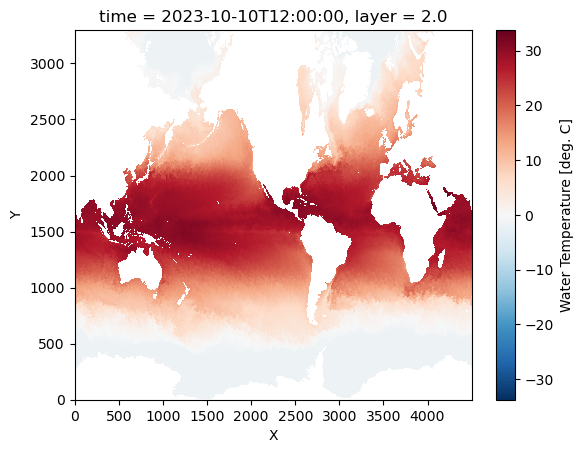

In [24]:
ds.temp.isel(layer=1).plot()

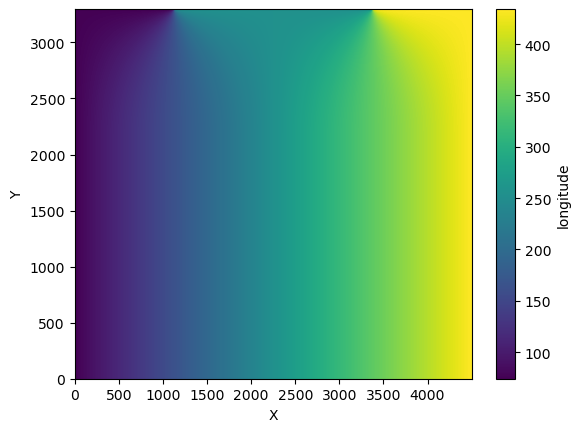

In [26]:
ds.longitude.plot()

In [27]:
ds.latitude.min(), ds.latitude.max()

(<xarray.DataArray 'latitude' ()> Size: 8B
 array(-78.63999939),
 <xarray.DataArray 'latitude' ()> Size: 8B
 array(89.97772217))

In [28]:
ds.longitude.min(), ds.longitude.max()

(<xarray.DataArray 'longitude' ()> Size: 8B
 array(74.12002563),
 <xarray.DataArray 'longitude' ()> Size: 8B
 array(434.1199646))